# ViT (Vision Transformer) Notebook
**Author: Joshua Owen Mangotang**

This notebook presents a practical exploration of Vision Transformer (ViT) representations on high-resolution remote sensing imagery from the ISPRS Potsdam dataset. We experiment with a pretrained ViT model (DINOv1) provided by TorchGeo and self-made decoder, with the goal of qualitatively examining the attention behavior and spatial structure sensitivity. This work is exploratory in nature and does not aim to provide a quantitative comparison or benchmark.

> **Note:** the pretrained DINO weights were not actually loaded into the encoder; see the note in Section 3.

## 0. Libraries Import

In [ ]:
import torch
torch.cuda.is_available() 

True

In [64]:
import os
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import rasterio
from pathlib import Path
from PIL import Image
import torchvision.transforms as T
from torchgeo.models import vit_small_patch16_224
from skimage.transform import resize
from IPython.display import Image, display
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 1. Potsdam Dataset Setup

The data set contains 38 patches (of the same size), each consisting of a true orthophoto (TOP) extracted from a larger TOP mosaic, see Figure below and a DSM. Each input image in the dataset was divided into image patches of size 300 × 300. These patches are divided into training, validation, and testing datasets and also labeled with the following labels: {`roads`, `buildings`, `low veg`, `trees`, `cars`, `clutter`}. The split is 70% training, 20% validation, and 10% testing.



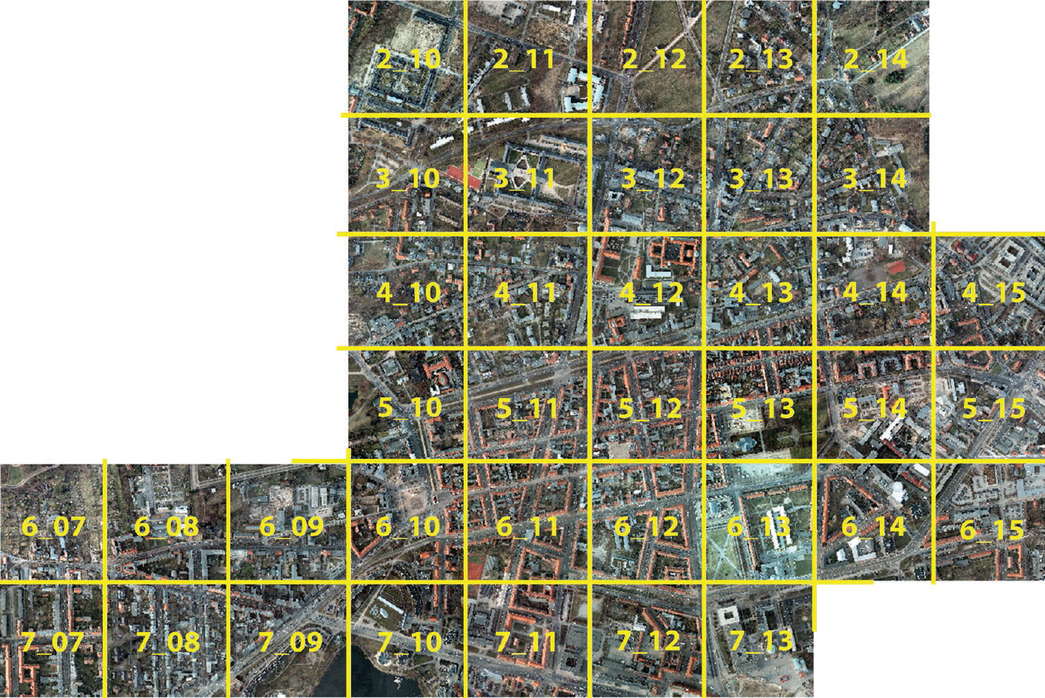

In [66]:
# Potsdam tiles example 
display(Image(filename="assets/potsdam_tiles.png"))

In [40]:
DATA_DIR = Path("dataset/potsdam/")
IMG_DIR = DATA_DIR / "Images"
LBL_DIR = DATA_DIR / "Labels" 

image_files = sorted(list(IMG_DIR.glob("*.tif")))
label_files = sorted(list(LBL_DIR.glob("*.tif")))

print(f"Found {len(image_files)} image tiles and {len(label_files)} label tiles")

Found 2400 image tiles and 2400 label tiles


In [41]:
# Split into train/val/test (70/20/10)
n_total = len(image_files)
n_train = int(0.7 * n_total)
n_val = int(0.2 * n_total)

train_image_files = image_files[:n_train]
train_label_files = label_files[:n_train]

val_image_files = image_files[n_train:n_train+n_val]
val_label_files = label_files[n_train:n_train+n_val]

test_image_files = image_files[n_train+n_val:]
test_label_files = label_files[n_train+n_val:]

print(f"\nDataset splits:")
print(f"  Training: {len(train_image_files)} samples")
print(f"  Validation: {len(val_image_files)} samples")
print(f"  Test: {len(test_image_files)} samples")


Dataset splits:
  Training: 1680 samples
  Validation: 480 samples
  Test: 240 samples


In [42]:
# Potsdam palette 
POTSDAM_PALETTE = {
    (255, 255, 255): 0,  # Impervious surfaces (white)
    (0, 0, 255): 1,      # Building (blue)
    (0, 255, 255): 2,    # Low vegetation (cyan)
    (0, 255, 0): 3,      # Tree (green)
    (255, 255, 0): 4,    # Car (yellow)
    (255, 0, 0): 5,      # Clutter/background (red)
    (0, 0, 0): 255       # Boundary/ignore (black)
}

# Function to convert RGB labels to class indices
def rgb_to_class(rgb_label):
    """Convert RGB label to class indices."""
    h, w = rgb_label.shape[:2]
    class_label = np.zeros((h, w), dtype=np.uint8)
    
    for rgb, class_id in POTSDAM_PALETTE.items():
        mask = np.all(rgb_label == rgb, axis=-1)
        class_label[mask] = class_id
    
    return class_label

# Check label format from first file
with rasterio.open(train_label_files[0]) as src:
    print(f"Label file bands: {src.count}")
    print(f"Label file dtype: {src.dtypes}")
    if src.count == 3:
        print("Detected RGB labels - will convert to class indices")
    else:
        print("Detected single-channel labels")

# Collect ALL unique labels from ALL training files
all_unique_labels = set()

for label_file in train_label_files:
    with rasterio.open(label_file) as src:
        if src.count == 3:
            # RGB label - convert to class
            label_rgb = src.read([1, 2, 3]).transpose(1, 2, 0)
            mask = rgb_to_class(label_rgb)
        else:
            mask = src.read(1)
        all_unique_labels.update(np.unique(mask))

all_unique_labels = sorted(all_unique_labels)
print(f"\nAll unique labels across dataset: {all_unique_labels}")

# Remove 255 (ignore index) from class count
valid_classes = [l for l in all_unique_labels if l != 255]
num_classes = len(valid_classes)

print(f"Valid classes (excluding 255): {valid_classes}")
print(f"Number of classes: {num_classes}")

Label file bands: 3
Label file dtype: ('uint8', 'uint8', 'uint8')
Detected RGB labels - will convert to class indices

All unique labels across dataset: [np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5)]
Valid classes (excluding 255): [np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5)]
Number of classes: 6


## 2. Preprocessing

Images are resized to a fixed resolution and normalized to produce tensors compatible with Vision Transformer inputs. A custom `PotsdamDataset` class handles image loading and preprocessing. `DataLoader` are then created for each dataset split.

In [43]:
# Preprocessing function for ViT models (resized and normalized)
def preprocess_for_vit(image, target_size=224):
    """Preprocess image for ViT input."""
    pil_image = Image.fromarray(image)
    
    transform = T.Compose([
        T.Resize(target_size, interpolation=T.InterpolationMode.BICUBIC),
        T.CenterCrop(target_size),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    tensor = transform(pil_image).unsqueeze(0)
    return tensor

# Custom Dataset class for Potsdam
class PotsdamDataset(Dataset):
    def __init__(self, image_files, label_files, target_size=224, ignore_index=255):
        self.image_files = image_files
        self.label_files = label_files
        self.target_size = target_size
        self.ignore_index = ignore_index
        
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        # Load image
        with rasterio.open(self.image_files[idx]) as src:
            img = src.read([1, 2, 3]).transpose(1, 2, 0)
        
        # Load label
        with rasterio.open(self.label_files[idx]) as src:
            if src.count == 3:
                # RGB label - convert to class indices
                label_rgb = src.read([1, 2, 3]).transpose(1, 2, 0)
                label = rgb_to_class(label_rgb)
            else:
                # Already class indices
                label = src.read(1)
        
        # Preprocess image
        img_tensor = preprocess_for_vit(img, self.target_size)
        
        # Resize label to match output size
        label_resized = resize(label, (self.target_size, self.target_size), 
                               order=0, preserve_range=True, anti_aliasing=False)
        
        # Keep 255 as ignore index (will be handled by loss function)
        label_tensor = torch.from_numpy(label_resized).long()
        
        return img_tensor.squeeze(0), label_tensor

In [44]:
# Create DataLoaders

train_dataset = PotsdamDataset(train_image_files, train_label_files, target_size=224)
val_dataset = PotsdamDataset(val_image_files, val_label_files, target_size=224)
test_dataset = PotsdamDataset(test_image_files, test_label_files, target_size=224)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0)

print(f"\nDataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")


DataLoaders created:
  Train batches: 420
  Val batches: 120
  Test batches: 240


### 2.1. Class Weights

Due to class imbalance in the dataset, class weights are introduced in the loss function to reduce bias toward dominant classes. This encourages the model to pay more attention to underrepresented classes during training.

In [45]:
# Calculate class weights to handle imbalance
print("Calculating class weights from training data...")
class_counts = np.zeros(num_classes)

for label_file in train_label_files:
    with rasterio.open(label_file) as src:
        if src.count == 3:
            label_rgb = src.read([1, 2, 3]).transpose(1, 2, 0)
            mask = rgb_to_class(label_rgb)
        else:
            mask = src.read(1)
    
    for class_id in range(num_classes):
        class_counts[class_id] += (mask == class_id).sum()

# Calculate inverse frequency weights
class_weights = 1.0 / (class_counts + 1)  # +1 to avoid division by zero
class_weights = class_weights / class_weights.sum() * num_classes  # Normalize
class_weights = torch.FloatTensor(class_weights).to(device)

print(f"Class weights: {class_weights}")

Calculating class weights from training data...
Class weights: tensor([0.2195, 0.2155, 0.3771, 0.6856, 3.1963, 1.3060], device='cuda:0')


## 3. ViT (DINOv1) Weight Load

A Vision Transformer (ViT) backbone with DINOv1 pretrained weights from `torchgeo.models` is used. The weights are obtained via self-supervised pretraining on the SSL4EO dataset, which is designed for large-scale Earth observation imagery.

### Brief explanation of ViT and DINO

**Vision Transformer (ViT)** processes an image as a sequence of fixed-size patches and models global context using self-attention.

**DINO** (self-**di**stillatio**n** with **no** labels) is a self-supervised learning method in which a student network is trained to match the representations produced by a teacher network under different image augmentations, enabling the model to learn meaningful visual representations without labeled data.

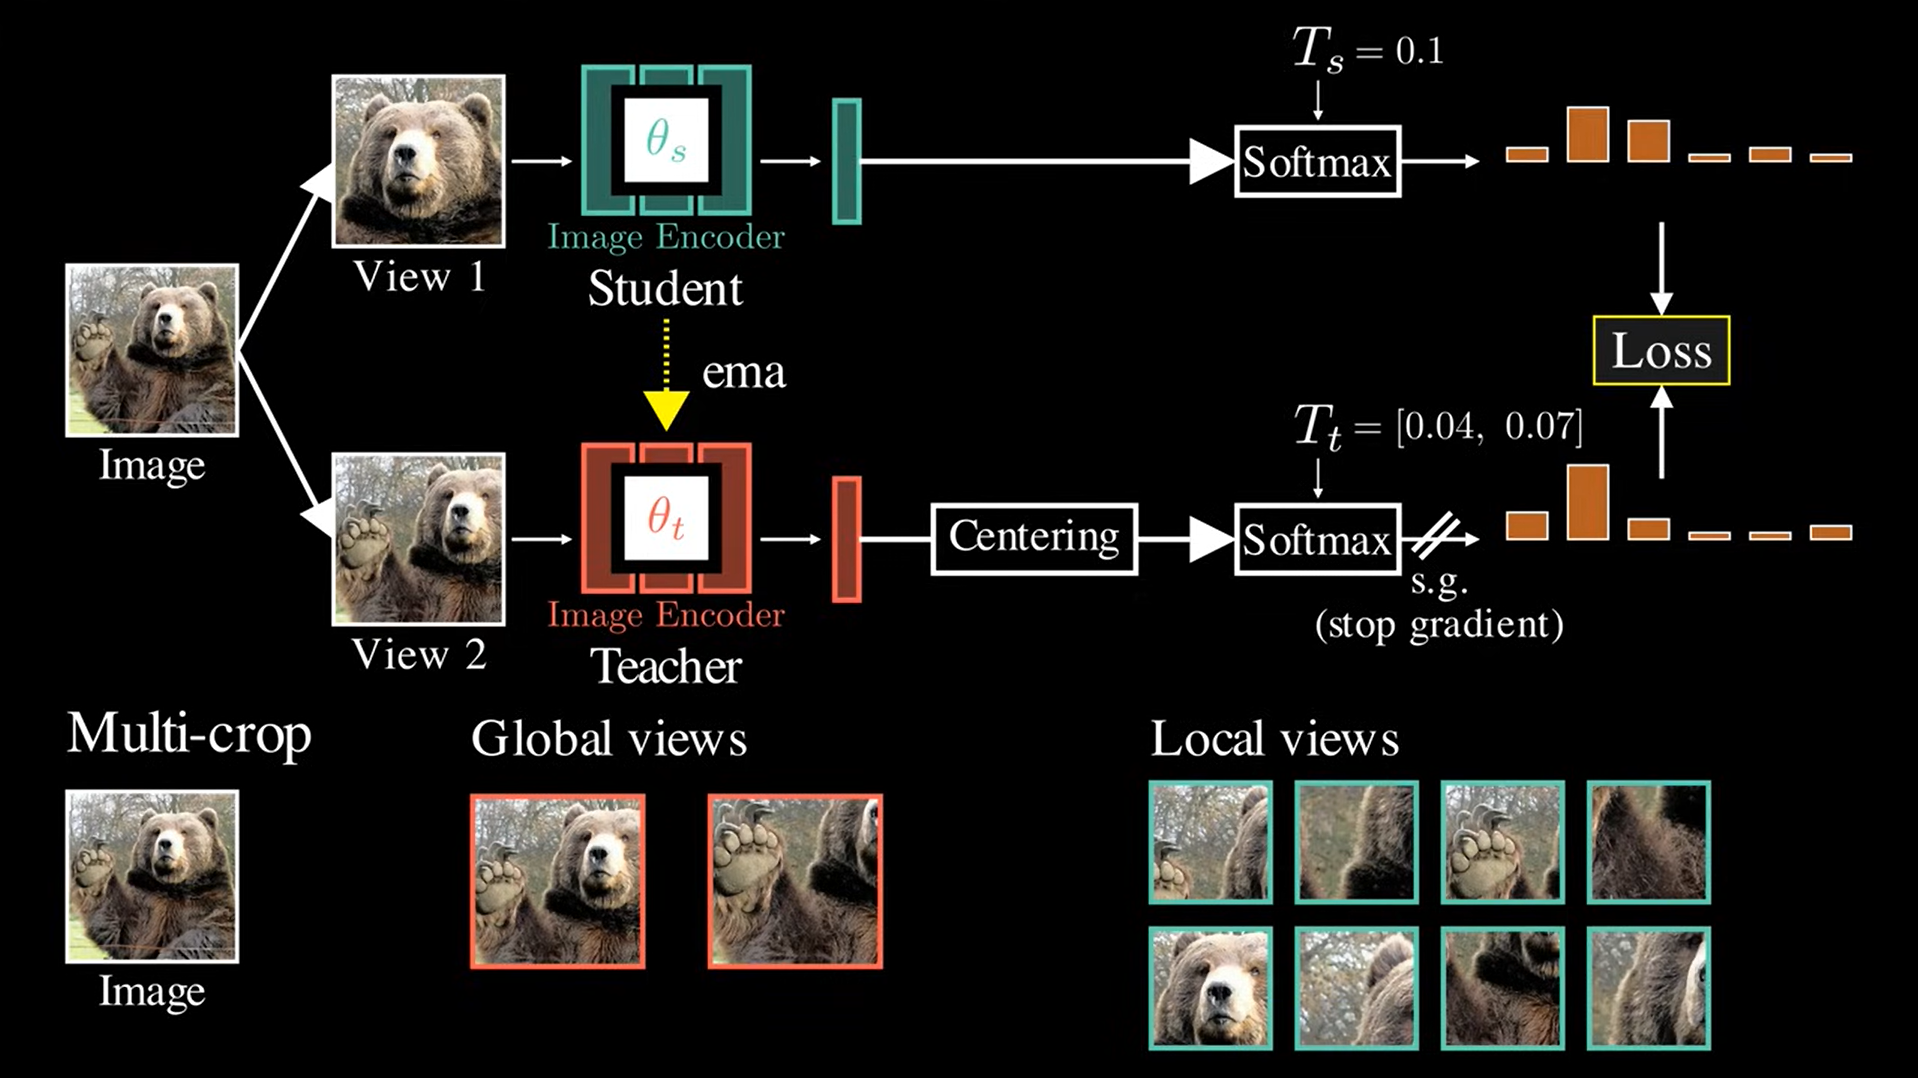

In [67]:
# DINO self-distilation with no labels architecture image 
display(Image(filename="assets/dino.png"))

In [46]:
# Load ViT DINO weights
VIT_WEIGHTS_PATH = Path("weights/B13_vits16_dino_0099_ckpt.pth")

# Create model
vit_dino = vit_small_patch16_224(weights=None)

# Load checkpoint
checkpoint = torch.load(VIT_WEIGHTS_PATH, map_location=device, weights_only=False)

# Extract state dict
if 'teacher' in checkpoint:
    state_dict = checkpoint['teacher']
elif 'model' in checkpoint:
    state_dict = checkpoint['model']
elif 'state_dict' in checkpoint:
    state_dict = checkpoint['state_dict']
elif 'student' in checkpoint:
    state_dict = checkpoint['student']
else:
    state_dict = checkpoint

# Load weights
vit_dino.load_state_dict(state_dict, strict=False)
vit_dino = vit_dino.to(device)
vit_dino.eval()

# Freeze the backbone
for param in vit_dino.parameters():
    param.requires_grad = False

print("ViT DINO (Small) loaded successfully")
print(f"Embedding dimension: 384")
print(f"Backbone frozen: {not next(vit_dino.parameters()).requires_grad}")

ViT DINO (Small) loaded successfully
Embedding dimension: 384
Backbone frozen: True


**Note on the pretrained weights.** The SSL4EO-S12 checkpoint stores its keys with a `backbone.` prefix and has a 13-band (Sentinel-2) patch embedding, while `vit_small_patch16_224` expects unprefixed keys and RGB input. With `strict=False`, `load_state_dict` skipped every key, so the frozen encoder in this notebook is randomly initialised and the results below come from the decoder trained on top of it. Loading the weights would need the prefix removed and the patch embedding reduced to the RGB bands.

## 4. Segmentation Decoder

Since the Vision Transformer encoder is used purely for feature extraction, a task-specific head is required. A quite simple segmentation decoder is therefore attached to the ViT encoder to perform semantic segmentation. The decoder is trained on the Potsdam dataset and is designed to operate on the patch-level features produced by the encoder.

In [47]:
class SegmentationDecoder(nn.Module):
    """Improved decoder head for semantic segmentation from ViT features."""
    
    def __init__(self, embed_dim, num_classes=6, grid_size=14, output_size=224):
        super().__init__()
        self.grid_size = grid_size
        self.output_size = output_size
        
        self.decoder = nn.Sequential(
            nn.Conv2d(embed_dim, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, num_classes, kernel_size=1)
        )
    
    def forward(self, patch_features):
        """
        Args:
            patch_features: (B, N, D) patch tokens
        Returns:
            logits: (B, num_classes, H, W)
        """
        B, N, D = patch_features.shape
        H = W = self.grid_size
        
        # Reshape to spatial grid
        x = patch_features.permute(0, 2, 1).reshape(B, D, H, W)
        
        # Apply decoder
        logits = self.decoder(x)
        
        # Upsample to output size
        logits = F.interpolate(
            logits, 
            size=(self.output_size, self.output_size), 
            mode='bilinear',
            align_corners=False
        )
        
        return logits

# Create decoder
decoder_vit = SegmentationDecoder(
    embed_dim=384,
    num_classes=num_classes,
    grid_size=14,  # 224/16 = 14
    output_size=224
).to(device)

print(f"\nCreated segmentation decoder for {num_classes} classes:")
print(f"Input: 384-dim features from 14×14 grid")
print(f"Output: {num_classes} classes at 224×224 resolution")


Created segmentation decoder for 6 classes:
Input: 384-dim features from 14×14 grid
Output: 6 classes at 224×224 resolution


### 4.1. Decoder Training Setup

In [54]:
optimizer = optim.Adam(decoder_vit.parameters(), lr=1e-3)
# Use class weights and ignore_index=255
criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=255)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

num_epochs = 20

print(f"\n✓ Training setup complete")
print(f"  Optimizer: Adam (lr=1e-3)")
print(f"  Loss: Weighted CrossEntropyLoss (ignore_index=255)")
print(f"  Epochs: {num_epochs}")


✓ Training setup complete
  Optimizer: Adam (lr=1e-3)
  Loss: Weighted CrossEntropyLoss (ignore_index=255)
  Epochs: 20


### 4.2. Decoder Training Loop

In [55]:
# Train and validation losses
train_losses = []
val_losses = []
best_val_loss = float('inf')

In [56]:
# Training loop
import time
from tqdm import tqdm

print("STARTING TRAINING")
time_start = time.time()

for epoch in range(num_epochs):
    # ============ TRAINING ============
    decoder_vit.train()
    train_loss = 0.0
    
    train_pbar = tqdm(
        train_loader,
        desc=f"Epoch [{epoch+1}/{num_epochs}] Training",
        leave=False
    )
    
    for batch_idx, (img_batch, label_batch) in enumerate(train_pbar):
        
        img_batch = img_batch.to(device)
        label_batch = label_batch.to(device)
        
        # Extract features (frozen backbone)
        with torch.no_grad():
            features = vit_dino.forward_features(img_batch)
            patch_tokens = features[:, 1:, :]  # Remove CLS token
        
        # Decode to segmentation
        logits = decoder_vit(patch_tokens)
        
        # Compute loss
        loss = criterion(logits, label_batch)
        
        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
        train_pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # ============ VALIDATION ============
    decoder_vit.eval()
    val_loss = 0.0
    
    val_pbar = tqdm(
        val_loader,
        desc=f"Epoch [{epoch+1}/{num_epochs}] Validation",
        leave=False
    )
    
    with torch.no_grad():
        for img_batch, label_batch in val_pbar:
            img_batch = img_batch.to(device)
            label_batch = label_batch.to(device)
            
            features = vit_dino.forward_features(img_batch)
            patch_tokens = features[:, 1:, :]
            logits = decoder_vit(patch_tokens)
            
            loss = criterion(logits, label_batch)
            val_loss += loss.item()
            
            val_pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    # Learning rate scheduling
    scheduler.step(avg_val_loss)
    
    # Save best model and optimizer state
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': decoder_vit.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_losses': train_losses,
            'val_losses': val_losses,
            'best_val_loss': best_val_loss,
            'num_classes': num_classes
        }, 'best_segment_decoder.pth')
    
    # Print progress
    print(
        f"Epoch [{epoch+1}/{num_epochs}] - "
        f"Train Loss: {avg_train_loss:.4f}, "
        f"Val Loss: {avg_val_loss:.4f}, "
        f"LR: {optimizer.param_groups[0]['lr']:.6f}"
    )

time_end = time.time()
total_time = time_end - time_start

print("\n✓ Training completed!")
print(f"  Best validation loss: {best_val_loss:.4f}")
print(f"  Total training time: {total_time:.2f} seconds")
print(f"  Average time per epoch: {total_time/num_epochs:.2f} seconds")

# Save final model checkpoint
torch.save({
    'epoch': num_epochs,
    'model_state_dict': decoder_vit.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'train_losses': train_losses,
    'val_losses': val_losses,
    'best_val_loss': best_val_loss,
    'num_classes': num_classes
}, 'final_segment_decoder.pth')
print("Saved final checkpoint: final_segment_decoder.pth")

STARTING TRAINING


Epoch [1/20] - Train Loss: 1.1361, Val Loss: 1.2236, LR: 0.001000


Epoch [2/20] - Train Loss: 0.9117, Val Loss: 1.1130, LR: 0.001000


Epoch [3/20] - Train Loss: 0.8660, Val Loss: 1.0339, LR: 0.001000


Epoch [4/20] - Train Loss: 0.8073, Val Loss: 0.9751, LR: 0.001000


...

Epoch [16/20] - Train Loss: 0.5063, Val Loss: 1.0890, LR: 0.000250


Epoch [17/20] - Train Loss: 0.4805, Val Loss: 1.0687, LR: 0.000250


Epoch [18/20] - Train Loss: 0.4609, Val Loss: 1.0431, LR: 0.000250


Epoch [19/20] - Train Loss: 0.4504, Val Loss: 1.1699, LR: 0.000250


Epoch [20/20] - Train Loss: 0.4479, Val Loss: 1.1215, LR: 0.000250

✓ Training completed!
  Best validation loss: 0.9751
  Total training time: 1972.87 seconds
  Average time per epoch: 98.64 seconds
Saved final checkpoint: final_segment_decoder.pth


### 4.3. Decoder Training Plot

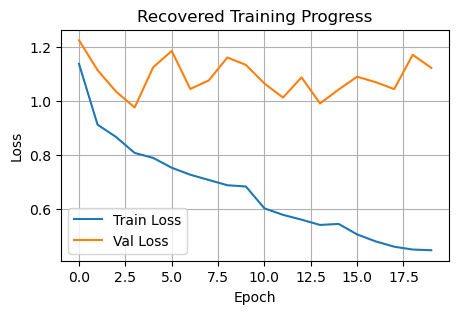

In [57]:
# Plot them
plt.figure(figsize=(5, 3))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Recovered Training Progress')
plt.legend()
plt.grid(True)
plt.show()

## 5. Evaluation on Test Split

After training, the best model checkpoint is used to perform evaluation on the test split. Predictions are compared to the ground-truth masks, and metrics such as per-class accuracy and overall accuracy are computed to assess the model's performance.

In [58]:
# Load best model for testing

if not os.path.exists('best_segment_decoder.pth'):
    print("WARNING: Checkpoint file not found!")
    
checkpoint = torch.load('best_segment_decoder.pth')
decoder_vit.load_state_dict(checkpoint['model_state_dict'])
decoder_vit.eval()

SegmentationDecoder(
  (decoder): Sequential(
    (0): Conv2d(384, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Conv2d(512, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 6, kernel_size=(1, 1), stride=(1, 1))
  )
)

In [59]:
# Evaluate on test set

print("TEST SET EVALUATION")

test_loss = 0.0
all_preds = []
all_labels = []

with torch.no_grad():
    for img_batch, label_batch in test_loader:
        img_batch = img_batch.to(device)
        label_batch = label_batch.to(device)
        
        features = vit_dino.forward_features(img_batch)
        patch_tokens = features[:, 1:, :]
        logits = decoder_vit(patch_tokens)
        
        # Calculate loss
        loss = criterion(logits, label_batch)
        test_loss += loss.item()
        
        # Get predictions
        pred = logits.argmax(dim=1)
        
        all_preds.append(pred.cpu().numpy())
        all_labels.append(label_batch.cpu().numpy())

# Flatten for metrics
all_preds = np.concatenate([p.flatten() for p in all_preds])
all_labels = np.concatenate([l.flatten() for l in all_labels])

# Calculate metrics
avg_test_loss = test_loss / len(test_loader)
# Only calculate accuracy on valid pixels (ignore 255)
valid_mask = all_labels != 255
accuracy = (all_preds[valid_mask] == all_labels[valid_mask]).mean()

print(f"\nTest Loss: {avg_test_loss:.4f}")
print(f"Test Accuracy (ignoring label 255): {accuracy*100:.2f}%")

# Define class names based on Potsdam dataset
class_names = {
    0: "Roads",
    1: "Buildings",
    2: "Low vegetation",
    3: "Trees",
    4: "Cars",
    5: "Clutter"
}

for class_id in range(num_classes):
    if class_id == 255:  # Skip ignore index
        continue
    mask = all_labels == class_id
    if mask.sum() > 0:
        class_acc = (all_preds[mask] == all_labels[mask]).mean()
        class_pixels = mask.sum()
        class_name = class_names.get(class_id, f"Unknown")
        print(f"  Class {class_id} ({class_name}): {class_acc*100:.2f}% ({class_pixels} pixels)")


TEST SET EVALUATION

Test Loss: 0.9631
Test Accuracy (ignoring label 255): 64.90%
  Class 0 (Roads): 69.00% (2235431 pixels)
  Class 1 (Buildings): 74.07% (2729979 pixels)
  Class 2 (Low vegetation): 59.18% (4236646 pixels)
  Class 3 (Trees): 69.37% (1972594 pixels)
  Class 4 (Cars): 81.67% (129999 pixels)
  Class 5 (Clutter): 36.52% (737591 pixels)


**Comments:** Even with class weights, there is still a clear performance gap between classes. Class 4 (Cars) achieves high accuracy (81.67%) despite being a small portion of the dataset (1.1%), showing that the model can reliably detect objects with clear shapes and edges. In contrast, Class 5 (Clutter/Background) performs poorly (36.52%) because it contains many visually diverse and ambiguous patterns. Overall, the model works well for structured objects like cars, roads, trees, and buildings, but struggles with clutter due to its heterogeneous nature.

### 5.1. Attention Mapping

Visualizing feature importance maps for test samples...


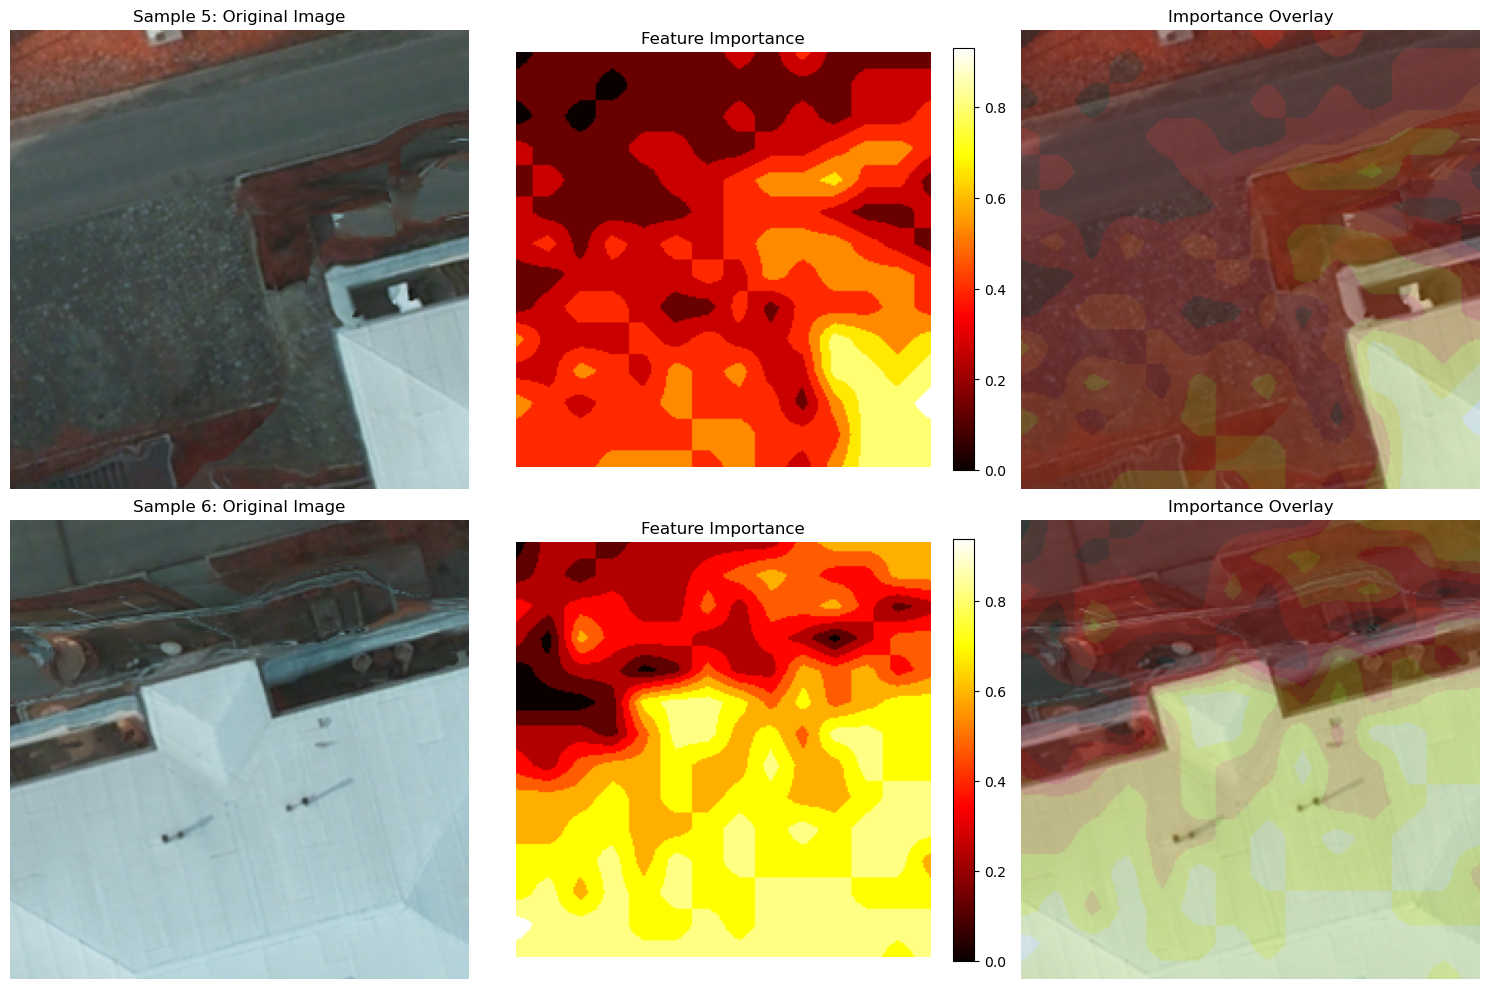

Visualized 2 test samples attention maps


In [60]:
# Attention maps for test samples
print("Visualizing feature importance maps for test samples...")

num_test_samples = min(len(test_dataset), 10)
indices = list(range(num_test_samples))
selected_indices = indices[4:6]

from scipy.ndimage import zoom

grid_size = 14
patch_size = 16

fig, axes = plt.subplots(len(selected_indices), 3, figsize=(15, 5*len(selected_indices)))
if len(selected_indices) == 1:
    axes = axes[np.newaxis, :]

for row, idx in enumerate(selected_indices):
    img, label = test_dataset[idx]
    img_tensor = img.unsqueeze(0).to(device)
    
    with torch.no_grad():
        features = vit_dino.forward_features(img_tensor)
        patch_tokens = features[:, 1:, :]  # (1, 196, D)
    
    # Feature magnitude as importance map
    patch_magnitude = torch.norm(patch_tokens.squeeze(0), dim=1)
    importance_map = patch_magnitude.reshape(grid_size, grid_size).cpu().numpy()
    
    # Upsample to image size
    importance_upsampled = zoom(importance_map, patch_size, order=1)
    
    # Normalize
    importance_norm = (
        importance_upsampled - importance_upsampled.min()
    ) / (
        importance_upsampled.max() - importance_upsampled.min() + 1e-6
    )
    
    # Denormalize image
    img_np = img.permute(1, 2, 0).cpu().numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_denorm = np.clip(img_np * std + mean, 0, 1)
    
    # Plot 1: Original Image
    axes[row, 0].imshow(img_denorm)
    axes[row, 0].set_title(f"Sample {idx+1}: Original Image")
    axes[row, 0].axis('off')
    
    # Plot 2: Feature Importance Map
    im = axes[row, 1].imshow(importance_norm, cmap='hot')
    axes[row, 1].set_title("Feature Importance")
    axes[row, 1].axis('off')
    plt.colorbar(im, ax=axes[row, 1], fraction=0.046)
    
    # Plot 3: Overlay
    axes[row, 2].imshow(img_denorm)
    axes[row, 2].imshow(importance_norm, cmap='hot', alpha=0.3)
    axes[row, 2].set_title("Importance Overlay")
    axes[row, 2].axis('off')

plt.tight_layout()
plt.show()

print(f"Visualized {len(selected_indices)} test samples attention maps")

**Comments:** Based on the feature importance maps, we can observe how the encoder see the image. The heatmaps highlight regions that contribute most to the learned representations, showing stronger responses on structured objects and boundaries while assigning lower importance to background regions.

### 5.2. Semantic Segmentation Predictions


Visualizing test samples with predictions...


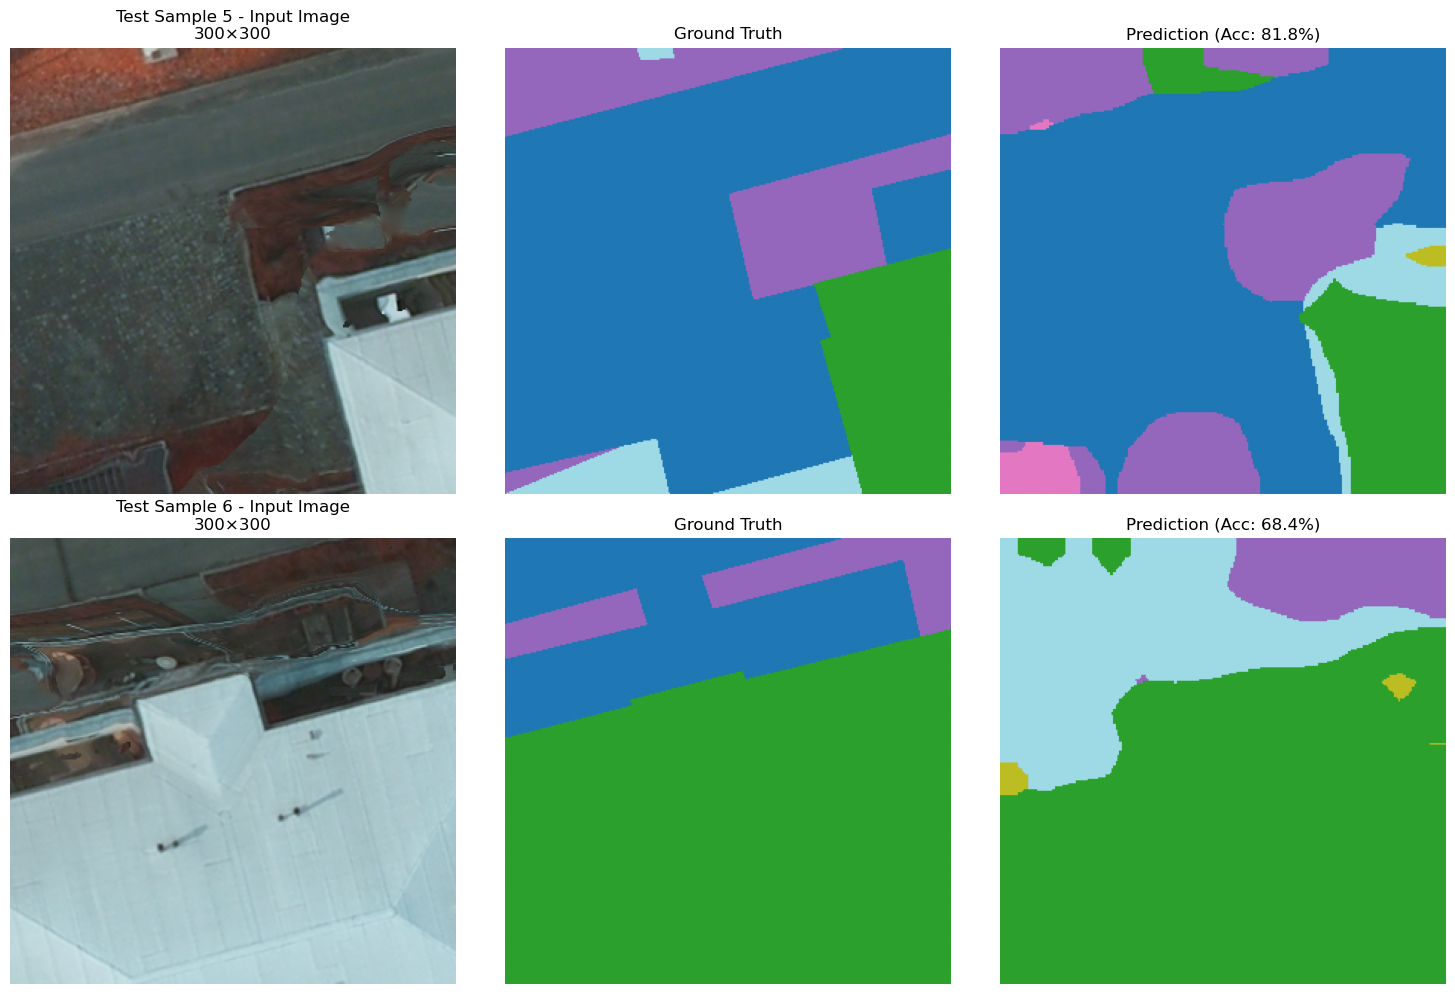

Visualized 2 test samples predictions


In [61]:
num_test_samples = min(len(test_dataset), 10)
indices = list(range(num_test_samples))
selected_indices = indices[4:6]  

fig, axes = plt.subplots(len(selected_indices), 3, figsize=(15, 5 * len(selected_indices)))
if len(selected_indices) == 1:
    axes = axes.reshape(1, -1)

print(f"\nVisualizing test samples with predictions...")

for row, idx in enumerate(selected_indices):
    # Load ORIGINAL full-resolution image
    with rasterio.open(test_image_files[idx]) as src:
        img_rgb_full = src.read([1, 2, 3]).transpose(1, 2, 0)
    
    # Load ORIGINAL full-resolution ground truth
    with rasterio.open(test_label_files[idx]) as src:
        if src.count == 3:
            label_rgb = src.read([1, 2, 3]).transpose(1, 2, 0)
            gt_mask_full = rgb_to_class(label_rgb)
        else:
            gt_mask_full = src.read(1)
    
    # Get prediction at 224x224
    img_tensor = preprocess_for_vit(img_rgb_full, 224).to(device)
    with torch.no_grad():
        features = vit_dino.forward_features(img_tensor)
        patch_tokens = features[:, 1:, :]
        logits = decoder_vit(patch_tokens)
        pred_mask_224 = logits.argmax(dim=1).squeeze().cpu().numpy()
    
    # Resize prediction back to original resolution
    pred_mask_full = resize(
        pred_mask_224,
        gt_mask_full.shape,
        order=0,
        preserve_range=True,
        anti_aliasing=False
    ).astype(np.uint8)
    
    # Compute accuracy (ignore void class 255)
    valid_pixels = gt_mask_full != 255
    sample_acc = (
        (pred_mask_full[valid_pixels] == gt_mask_full[valid_pixels]).mean() * 100
        if valid_pixels.sum() > 0 else 0.0
    )
    
    # Plot
    axes[row, 0].imshow(img_rgb_full)
    axes[row, 0].set_title(
        f"Test Sample {idx+1} - Input Image\n"
        f"{img_rgb_full.shape[0]}×{img_rgb_full.shape[1]}"
    )
    axes[row, 0].axis('off')
    
    axes[row, 1].imshow(
        gt_mask_full,
        cmap='tab20',
        vmin=0,
        vmax=num_classes - 1
    )
    axes[row, 1].set_title("Ground Truth")
    axes[row, 1].axis('off')
    
    axes[row, 2].imshow(
        pred_mask_full,
        cmap='tab20',
        vmin=0,
        vmax=num_classes - 1
    )
    axes[row, 2].set_title(f"Prediction (Acc: {sample_acc:.1f}%)")
    axes[row, 2].axis('off')

plt.tight_layout()
plt.show()

print(f"Visualized {len(selected_indices)} test samples predictions")

**Comment:** The model captures the dominant classes and overall spatial layout well, which explains the relatively high pixel accuracy. However, boundary regions and smaller classes are still inconsistent, with visible class bleeding and shape distortion compared to the ground truth. This indicates that the model relies more on coarse semantic cues than precise edge localization, especially in complex or mixed-class areas.

In [63]:
# Summary
print("Training, Validation, and Test Summary:")
print(f"- Model: ViT DINO Small + Segmentation Decoder")
print(f"- Training samples: {len(train_dataset)}")
print(f"- Validation samples: {len(val_dataset)}")
print(f"- Test samples: {len(test_dataset)}")
print(f"- Number of classes: {num_classes}")
print(f"- Best validation loss: {best_val_loss:.4f}")
print(f"- Test loss: {avg_test_loss:.4f}")
print(f"- Test accuracy: {accuracy*100:.2f}%")


Training, Validation, and Test Summary:
- Model: ViT DINO Small + Segmentation Decoder
- Training samples: 1680
- Validation samples: 480
- Test samples: 240
- Number of classes: 6
- Best validation loss: 0.9751
- Test loss: 0.9631
- Test accuracy: 64.90%


## Summary and Key Takeaways

- This work uses a **ViT-Small encoder pretrained with DINO v1 (SSL4EO)** and a **custom segmentation decoder** for semantic segmentation on the **Potsdam** dataset (6 classes).
- The encoder learns **strong global and shape-based features**, so the model performs well on classes with clear structure and edges such as **buildings, roads, trees, and cars**.
- The overall **test accuracy is 64.90%**, but this is mainly driven by dominant classes.
- Classes with **high visual variability** (e.g. clutter/background) are still hard to predict, even with class weighting.
- The model struggles with **small objects, sharp boundaries, random and heterogenous shapes**, which is expected due to the **patch-based nature of ViT** and a relatively simple decoder.
- Class weighting helps but is **not enough to fully solve class imbalance**.
- Overall, DINO-pretrained ViT works quite well as a feature extractor, but **better decoders, multi-scale features, or boundary-aware methods** are needed for stronger pixel-level segmentation performance.

- The pretrained weights were not actually loaded (see the note in Section 3), so these observations describe a frozen, randomly initialised ViT encoder with a trained decoder.

## Citations and Sources

- **ISPRS 2D Semantic Labeling – Potsdam Dataset**  
  by ISPRS (2024) [*link*](https://www.isprs.org/resources/datasets/benchmarks/UrbanSemLab/2d-sem-label-potsdam.aspx)

- **An Image Is Worth 16×16 Words: Transformers for Image Recognition at Scale**  
  by Dosovitskiy et al. (2020) [*link*](https://arxiv.org/abs/2010.11929)

- **Emerging Properties in Self-Supervised Vision Transformers**  
  by Caron et al. (2021) [*link*](https://arxiv.org/abs/2104.14294)

- **How AI Taught Itself to See (DINOv3)**  
  by Jia-Bin Huang (2025) [*link*](https://www.youtube.com/watch?v=oGTasd3cliM)

- **Attention in transformers, step-by-step | Deep Learning Chapter 6**  
  by 3Blue1Brown (2024) [*link*](youtube.com/watch?v=eMlx5fFNoYc&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi&index=7)



